In [34]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import seaborn as sns

In [30]:
from pyspi.data import Data
from pyspi.calculator import Calculator
from pyspi.statistics.basic import Covariance, CrossCorrelation
from pyspi.statistics.infotheory import DirectedInfo

In [43]:
from scripts.utils import std

In [49]:
cols = ['#E8A83C', '#4A6FA5']
pal = sns.color_palette(cols)
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams.update({'font.size':14})

## Exploring an example

Example subject pairs: (103, 203), (108, 208)  
Example word: birthday  
Example conditions: ground (103), board (108)

We load interpolated merged data from `example/merged`.


In [5]:
ground = pd.read_csv('../example/merged/103_203.csv')
ground = std(ground, 'pitch')
board  = pd.read_csv('../example/merged/108_208.csv')
board  = std(board, 'pitch')

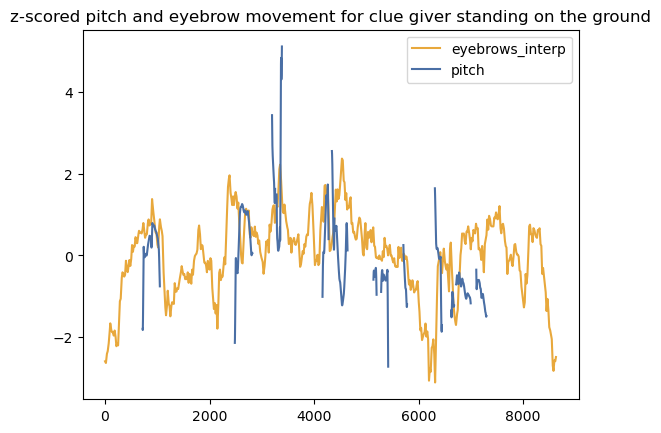

In [39]:
ground[['eyebrows_interp', 'pitch']].plot(color=cols)
plt.title('z-scored pitch and eyebrow movement for clue giver standing on the ground');

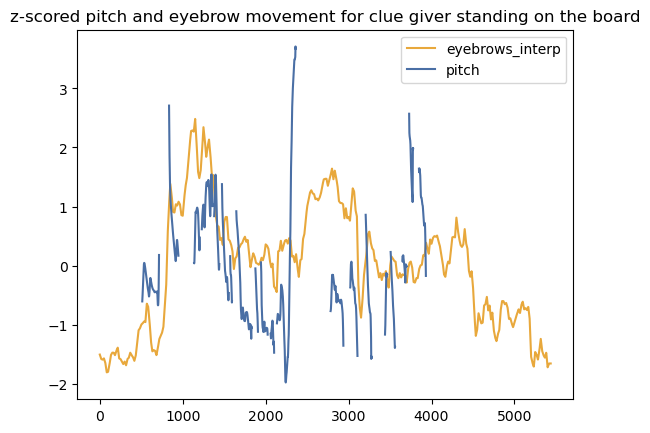

In [40]:
board[['eyebrows_interp', 'pitch']].plot(color=cols)
plt.title('z-scored pitch and eyebrow movement for clue giver standing on the board');

In [10]:
groundna = ground.dropna()
boardna  = board.dropna()

In [11]:
grounddata = Data(np.stack([ list(groundna['eyebrows_interp']), list(groundna['pitch']) ]))
boarddata  = Data(np.stack([ list(boardna['eyebrows_interp']),  list(boardna['pitch']) ]))

[1/2] Skipping detrending of time series in the dataset...
[2/2] Normalising (z-scoring) each time series in the dataset...

[1/2] Skipping detrending of time series in the dataset...
[2/2] Normalising (z-scoring) each time series in the dataset...



Below are results obtained by running `mutualinfo.py`, currently not supported to import in this notebook due to dependency mismatch.JVM started using jpype1

In [76]:
results = dict()

In [77]:
results['MI (Gaussian)'] = {
    'ground': 0.0334946922366182,
    'board' : 0.027767996549680103 }
results['MI (Kraskov)'] = {
    'ground': 1.437130920021727,
    'board' : 1.4333776439460584 }

In [78]:
results['covariance'] = {
    'ground': Covariance().multivariate(data = grounddata)[0,1],
    'board' : Covariance().multivariate(data = boarddata)[0,1] }

In [79]:
results['correlation'] = {
    'ground': st.pearsonr(groundna['eyebrows_interp'], groundna['pitch']).statistic,
    'board' : st.pearsonr(boardna['eyebrows_interp'],  boardna['pitch']).statistic }

In [80]:
results

{'MI (Gaussian)': {'ground': 0.0334946922366182,
  'board': 0.027767996549680103},
 'MI (Kraskov)': {'ground': 1.437130920021727, 'board': 1.4333776439460584},
 'covariance': {'ground': np.float64(0.25443062931135635),
  'board': np.float64(0.23229993139161548)},
 'correlation': {'ground': np.float64(0.25454836676129194),
  'board': np.float64(0.2324263875328194)}}

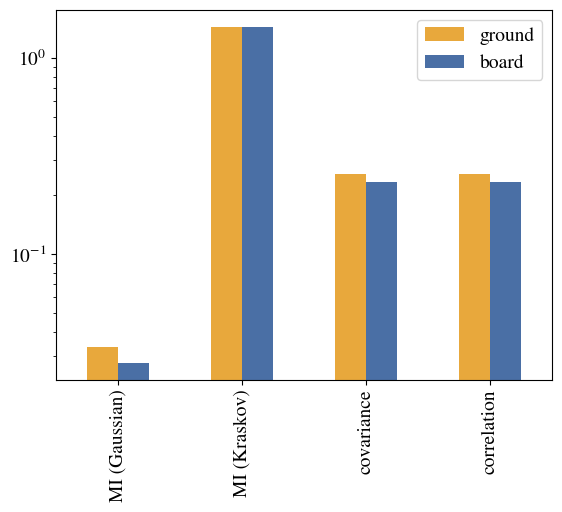

In [81]:
pd.DataFrame(results).T.plot(kind='bar', color=cols)
plt.semilogy()
plt.savefig('../figures/pairwise_interactions.png', dpi=200, bbox_inches="tight")

In [91]:
tdmi = pd.read_csv('../data/mutualinfo/eyebrow_pitch_univar_tdmi.csv')

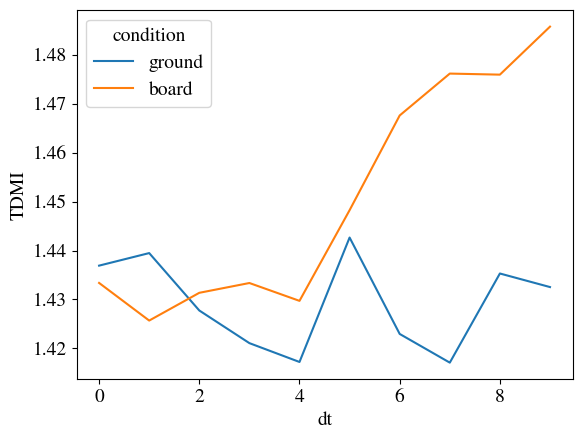

In [94]:
sns.lineplot(data = tdmi, x = 'dt', y = 'TDMI', hue = 'condition')
plt.savefig('../figures/tdmi_pitch_vs_brow.png')

### PySPI

In [32]:
calcg = Calculator(dataset = grounddata, subset='fast');
calcb = Calculator(dataset = boarddata, subset='fast');

Loading configuration file: /nix/store/y8a2znv0p5cl7w5sdavhqvd504z2ch51-source/pyspi/fast_config.yaml
*** Importing module .statistics.basic
[0] Adding SPI .statistics.basic.Covariance(x,y,{'estimator': 'EmpiricalCovariance'})
Succesfully initialised SPI with identifier "cov_EmpiricalCovariance" and labels ['basic', 'unordered', 'linear', 'undirected', 'signed']
[1] Adding SPI .statistics.basic.Covariance(x,y,{'estimator': 'GraphicalLasso'})
Succesfully initialised SPI with identifier "cov_GraphicalLasso" and labels ['basic', 'unordered', 'linear', 'undirected', 'signed']
[2] Adding SPI .statistics.basic.Covariance(x,y,{'estimator': 'GraphicalLassoCV'})
Succesfully initialised SPI with identifier "cov_GraphicalLassoCV" and labels ['basic', 'unordered', 'linear', 'undirected', 'signed']
[3] Adding SPI .statistics.basic.Covariance(x,y,{'estimator': 'LedoitWolf'})
Succesfully initialised SPI with identifier "cov_LedoitWolf" and labels ['basic', 'unordered', 'linear', 'undirected', 'signed

ModuleNotFoundError: No module named 'tslearn'

In [24]:
calcg.compute()

NameError: name 'calcg' is not defined